# 1. What is the mean duration (in seconds) of the Jazz genre stems in train dataset? 

In [2]:
import pandas as pd
from pathlib import Path

In [4]:
data_path = Path("../data/raw/messy_mashup/genres_stems")

# Assert that the data path exists

assert data_path.exists(), f"Data path {data_path} does not exist."

print(f"Data path {data_path} exists.")

Data path ../data/raw/messy_mashup/genres_stems exists.


In [6]:
jazz_path = data_path / "jazz"

assert jazz_path.exists(), f"Jazz genre path {jazz_path} does not exist."

print(f"Jazz genre path {jazz_path} exists.")

Jazz genre path ../data/raw/messy_mashup/genres_stems/jazz exists.


In [10]:
import os
import numpy as np
import torchaudio
from tqdm import tqdm

def compute_mean_duration_jazz(jazz_path):    
    durations = []
    
    for root, dirs, files in tqdm(os.walk(jazz_path)):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                
                try:
                    waveform, sr = torchaudio.load(file_path)
                    duration = waveform.shape[1] / sr
                    durations.append(duration)
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
    
    mean_duration = np.mean(durations)
    
    print(f"Total Jazz stems: {len(durations)}")
    print(f"Mean duration (seconds): {mean_duration:.4f}")
    
    return mean_duration


compute_mean_duration_jazz(jazz_path)

101it [00:12,  7.79it/s]

Total Jazz stems: 400
Mean duration (seconds): 30.0330


np.float64(30.032979591836728)

# 2. What are the unique sample rates present in the dataset? Enter your answer as a comma separated list. Example: [40000, 50000, 60000]

In [13]:
import os
import torchaudio
from tqdm import tqdm

def get_unique_sample_rates(root_paths):
    sample_rates = set()
    
    for root_path in tqdm(root_paths):
        for root, dirs, files in tqdm(os.walk(root_path)):
            for file in files:
                if file.endswith(".wav"):
                    file_path = os.path.join(root, file)
                    
                    try:
                        info = torchaudio.info(file_path)
                        sample_rates.add(info.sample_rate)
                    except Exception as e:
                        print(f"Error reading {file_path}: {e}")
    
    return sorted(list(sample_rates))

# Root path

root_data = Path("../data/raw/messy_mashup")


# Paths (adjust if needed)
root_paths = [
    root_data / "genres_stems",
    root_data / "ESC-50-master/audio",
    root_data / "mashups"
]

unique_sample_rates = get_unique_sample_rates(root_paths)

print(unique_sample_rates)

1011it [01:21, 12.34it/s]00<?, ?it/s]
1it [00:23, 23.41s/it]01:21<02:43, 81.91s/it]
1it [00:39, 39.14s/it]01:45<00:47, 47.50s/it]
100%|██████████| 3/3 [02:24<00:00, 48.16s/it]

[22050, 44100]


# 3. How many corrupted or zero-byte audio files are present in the train dataset?

In [14]:
import os
import torchaudio
from tqdm import tqdm

def count_corrupted_files(train_path):
    zero_byte_count = 0
    corrupted_count = 0
    
    for root, dirs, files in tqdm(os.walk(train_path)):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                
                # Check zero-byte
                if os.path.getsize(file_path) == 0:
                    zero_byte_count += 1
                    continue
                
                # Check corrupted
                try:
                    _ = torchaudio.info(file_path)
                except Exception:
                    corrupted_count += 1
    
    total = zero_byte_count + corrupted_count
    
    print("Zero-byte files:", zero_byte_count)
    print("Corrupted files:", corrupted_count)
    print("Total corrupted or zero-byte:", total)
    
    return total


# Replace with actual train path if needed
train_path = root_data / "genres_stems"

total_bad_files = count_corrupted_files(train_path)

1011it [01:27, 11.52it/s]

Zero-byte files: 0
Corrupted files: 0
Total corrupted or zero-byte: 0


# 4. What is the average peak amplitude (in dB) for vocal stems in train dataset? 

In [16]:
import os
import torch
import torchaudio
import numpy as np
from tqdm import tqdm

def compute_avg_peak_db(train_path):
    peak_db_values = []
    
    for root, dirs, files in tqdm(os.walk(train_path)):
        for file in files:
            if file.lower() == "vocals.wav":
                file_path = os.path.join(root, file)
                
                try:
                    waveform, sr = torchaudio.load(file_path)
                    
                    # Convert to mono if stereo
                    if waveform.shape[0] > 1:
                        waveform = torch.mean(waveform, dim=0, keepdim=True)
                    
                    peak = torch.max(torch.abs(waveform)).item()
                    
                    # Avoid log(0)
                    if peak > 0:
                        peak_db = 20 * np.log10(peak)
                        peak_db_values.append(peak_db)
                
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
    
    avg_peak_db = np.mean(peak_db_values)
    
    print("Number of vocal stems:", len(peak_db_values))
    print("Average peak amplitude (dB):", round(avg_peak_db, 4))
    
    return avg_peak_db


train_path = root_data / "genres_stems"
avg_peak = compute_avg_peak_db(train_path)

1011it [01:24, 11.92it/s]

Number of vocal stems: 1000
Average peak amplitude (dB): -12.4949


# 5. What is the mean spectral centroid for 'blues' genre in the train dataset?

In [18]:
import os
import librosa
import numpy as np
from tqdm import tqdm

def compute_mean_spectral_centroid(train_path):
    blues_path = os.path.join(train_path, "blues")
    file_means = []
    
    for root, dirs, files in tqdm(os.walk(blues_path)):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                
                try:
                    y, sr = librosa.load(file_path, sr=None)
                    
                    spectral_centroids = librosa.feature.spectral_centroid(
                        y=y,
                        sr=sr
                    )
                    
                    # Mean centroid for this file
                    file_mean = np.mean(spectral_centroids)
                    file_means.append(file_mean)
                
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
    
    overall_mean = np.mean(file_means)
    
    print("Number of blues files:", len(file_means))
    print("Mean Spectral Centroid:", round(overall_mean, 4))
    
    return overall_mean


train_path = root_data / "genres_stems"
mean_centroid = compute_mean_spectral_centroid(train_path)

101it [01:01,  1.65it/s]

Number of blues files: 400
Mean Spectral Centroid: 2296.7827


# 6. Which genre in the train dataset has the highest mean spectral centroid? 

In [19]:
import os
import librosa
import numpy as np
from tqdm import tqdm

def compute_genre_centroids(train_path):
    genre_means = {}
    
    for genre in tqdm(os.listdir(train_path)):
        genre_path = os.path.join(train_path, genre)
        
        if os.path.isdir(genre_path):
            file_means = []
            
            for root, dirs, files in tqdm(os.walk(genre_path)):
                for file in files:
                    if file.endswith(".wav"):
                        file_path = os.path.join(root, file)
                        
                        try:
                            y, sr = librosa.load(file_path, sr=None)
                            centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
                            file_means.append(np.mean(centroid))
                        except:
                            continue
            
            if len(file_means) > 0:
                genre_means[genre] = np.mean(file_means)
    
    # Find genre with highest mean centroid
    highest_genre = max(genre_means, key=genre_means.get)
    
    print("Mean Spectral Centroid per Genre:")
    for g, val in genre_means.items():
        print(f"{g}: {round(val, 2)}")
    
    print("\nHighest Mean Spectral Centroid Genre:", highest_genre)
    
    return highest_genre, genre_means


train_path = root_data / "genres_stems"
highest_genre, genre_means = compute_genre_centroids(train_path)

101it [01:04,  1.57it/s]0:00<?, ?it/s]
101it [01:01,  1.64it/s]1:04<09:38, 64.28s/it]
101it [01:02,  1.63it/s]2:05<08:21, 62.63s/it]
101it [01:01,  1.63it/s]3:07<07:16, 62.37s/it]
101it [01:02,  1.61it/s]4:09<06:12, 62.14s/it]
101it [01:02,  1.61it/s]5:12<05:12, 62.42s/it]
101it [01:01,  1.64it/s]6:15<04:10, 62.56s/it]
101it [01:02,  1.62it/s]7:16<03:06, 62.25s/it]
101it [01:02,  1.63it/s]8:19<02:04, 62.23s/it]
101it [01:03,  1.59it/s]9:21<01:02, 62.19s/it]
100%|██████████| 10/10 [10:24<00:00, 62.46s/it]

Mean Spectral Centroid per Genre:
reggae: 2404.57
pop: 2440.88
country: 2266.72
classical: 1674.79
rock: 2250.08
blues: 2296.78
disco: 2454.15
jazz: 2544.11
metal: 2579.32
hiphop: 2370.79

Highest Mean Spectral Centroid Genre: metal


# 7. How many stem audio files in the train dataset contain silence in the first 0.5 seconds?  

In [20]:
import os
import torch
import torchaudio
import numpy as np
from tqdm import tqdm

def count_silence_first_half_sec(train_path, threshold=1e-4):
    silence_count = 0
    
    for root, dirs, files in tqdm(os.walk(train_path)):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                
                try:
                    waveform, sr = torchaudio.load(file_path)
                    
                    # Convert to mono
                    if waveform.shape[0] > 1:
                        waveform = torch.mean(waveform, dim=0, keepdim=True)
                    
                    # Number of samples in 0.5 sec
                    num_samples = int(0.5 * sr)
                    
                    # Ensure file is long enough
                    if waveform.shape[1] >= num_samples:
                        segment = waveform[:, :num_samples]
                    else:
                        segment = waveform
                    
                    # Compute RMS
                    rms = torch.sqrt(torch.mean(segment**2)).item()
                    
                    if rms < threshold:
                        silence_count += 1
                        
                except:
                    continue
    
    print("Stem files with silence in first 0.5 sec:", silence_count)
    return silence_count


train_path = root_data / "genres_stems"
silence_files = count_silence_first_half_sec(train_path)

1011it [05:28,  3.08it/s]

Stem files with silence in first 0.5 sec: 519


# Section 2:

/tmp/ipykernel_8020/4146217304.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]


Validation Macro F1 Score: 0.2336

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.31      0.40      0.35        10
   classical       0.20      0.60      0.30        10
     country       0.00      0.00      0.00        10
       disco       0.18      0.30      0.22        10
      hiphop       0.33      0.20      0.25        10
        jazz       0.17      0.10      0.12        10
       metal       0.43      0.30      0.35        10
         pop       0.50      0.20      0.29        10
      reggae       0.27      0.30      0.29        10
        rock       0.50      0.10      0.17        10

    accuracy                           0.25       100
   macro avg       0.29      0.25      0.23       100
weighted avg       0.29      0.25      0.23       100



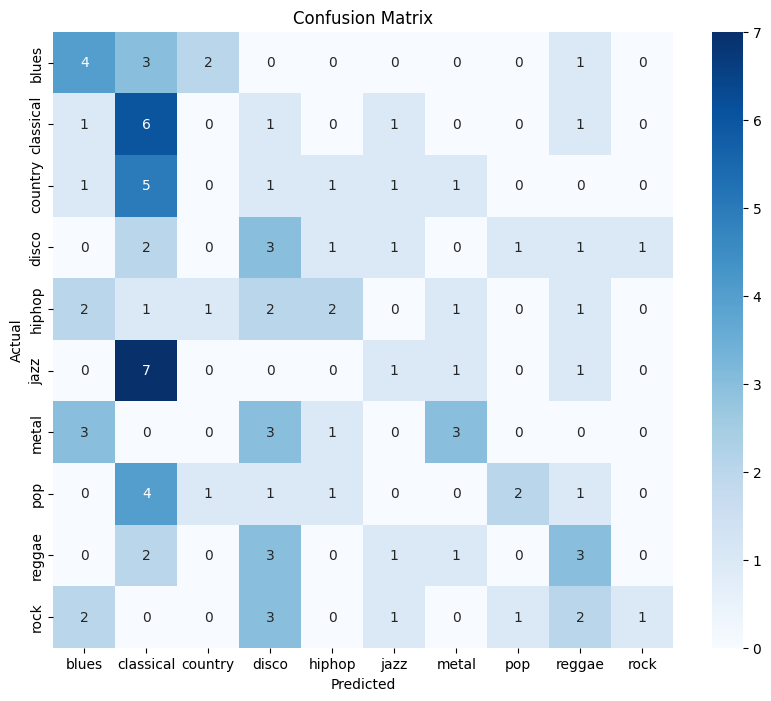

blues: TP=4, TN=81, FP=9, FN=6
classical: TP=6, TN=66, FP=24, FN=4
country: TP=0, TN=86, FP=4, FN=10
disco: TP=3, TN=76, FP=14, FN=7
hiphop: TP=2, TN=86, FP=4, FN=8
jazz: TP=1, TN=85, FP=5, FN=9
metal: TP=3, TN=86, FP=4, FN=7
pop: TP=2, TN=88, FP=2, FN=8
reggae: TP=3, TN=82, FP=8, FN=7
rock: TP=1, TN=89, FP=1, FN=9


In [21]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = root_data
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# --- 4. Evaluation ---

# Predicted values
y_pred = clf.predict(X_val)

# Macro F1 score
macro_f1 = f1_score(y_val, y_pred, average='macro')

# Confusion matrix
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

# Classification report
cr = classification_report(y_val, y_pred)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

# --- 5. Confusion Matrix Visualization ---
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=GENRES,
            yticklabels=GENRES,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# --- 6. Compute TP, TN, FP, FN for each genre ---
for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    print(f"{genre}: TP={TP}, TN={TN}, FP={FP}, FN={FN}")